# Notebook Objective

# 04 Feature Engineering

This notebook transforms the preprocessed C-MAPSS time series into model-ready feature representations.

The main objectives are:

- use the preprocessing workflow from Notebook 03
- create sliding windows for engine trajectories
- extract statistical features from each sensor window
- assign the RUL target at the end of each window
- build tabular feature matrices for classical machine learning models
- prepare the foundation for sequence-based deep learning models
- validate that engineered features are aligned with engine units, cycles and targets

This notebook does not train models. Model training and evaluation are handled in Notebook 05.

# Imports and Project Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.data_loading import (
    load_cmapss_dataset,
    DATASET_IDS,
    SETTING_NAMES,
    SENSOR_NAMES,
)

from src.preprocessing import (
    add_rul_to_training_data,
    add_capped_rul,
    prepare_test_rul,
    identify_constant_features,
    remove_features,
    define_feature_columns,
    create_feature_target_frames,
    split_train_validation_by_engine,
    create_split_feature_target_frames,
    scale_feature_sets,
)

from src.features import (
    create_sliding_windows,
    extract_statistical_window_features,
)

from src.config import load_config, flatten_config


# Load and Preprocess Dataset

The selected C-MAPSS subset is loaded and preprocessed using the same modular workflow as in Notebook 03. This ensures that feature engineering starts from leakage-free train, validation and test splits.

In [3]:
config = load_config()
flat_config = flatten_config(config)

CURRENT_DATASET = flat_config["CURRENT_DATASET"]
RUL_CAP = flat_config["RUL_CAP"]
VALIDATION_SIZE = flat_config["VALIDATION_SIZE"]
RANDOM_STATE = flat_config["RANDOM_STATE"]
WINDOW_SIZE = flat_config["WINDOW_SIZE"]
WINDOW_STEP = flat_config["WINDOW_STEP"]

index_cols = flat_config["INDEX_COLS"]
target_cols = flat_config["TARGET_COLS"]
helper_cols = flat_config["HELPER_COLS"]
target_col = flat_config["TARGET_COL"]

model_config = config["models"]
conformal_config = config["conformal"]
simulation_config = config["simulation"]

if CURRENT_DATASET not in DATASET_IDS:
    raise ValueError(f"Unknown dataset: {CURRENT_DATASET}")

df_train_raw, df_test_raw, df_test_rul_raw = load_cmapss_dataset(CURRENT_DATASET)

df_train_rul = add_rul_to_training_data(df_train_raw)
df_train_rul = add_capped_rul(
    df_train_rul,
    cap=RUL_CAP,
    source_col="RUL",
    target_col="RUL_capped"
)

df_test_rul_summary = prepare_test_rul(
    df_test_raw,
    df_test_rul_raw
)

candidate_feature_cols = SETTING_NAMES + SENSOR_NAMES

constant_features = identify_constant_features(
    df_train_raw,
    candidate_feature_cols
)

df_train_preprocessed = remove_features(
    df_train_rul,
    constant_features
)

df_test_preprocessed = remove_features(
    df_test_raw,
    constant_features
)


In [4]:
feature_cols = define_feature_columns(
    df_train_preprocessed,
    index_cols=index_cols,
    target_cols=target_cols,
    helper_cols=helper_cols
)

X_train_full, y_train_full, X_test_full = create_feature_target_frames(
    df_train_preprocessed,
    df_test_preprocessed,
    feature_cols=feature_cols,
    target_col=target_col,
    index_cols=index_cols
)


In [5]:
df_train_split, df_val_split, train_engines, val_engines = split_train_validation_by_engine(
    df_train_preprocessed,
    validation_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    engine_col="engine"
)

X_train, y_train, X_val, y_val = create_split_feature_target_frames(
    df_train_split,
    df_val_split,
    feature_cols=feature_cols,
    target_col=target_col,
    index_cols=index_cols
)

In [6]:
X_train_scaled, X_val_scaled, X_test_scaled, scaler = scale_feature_sets(
    X_train,
    X_val,
    X_test_full,
    feature_cols=feature_cols
)

In [7]:
print(f"Current dataset: {CURRENT_DATASET}")
print(f"Number of input features: {len(feature_cols)}")
print(f"Removed constant features: {len(constant_features)}")

print(f"X_train shape:      {X_train.shape}")
print(f"y_train shape:      {y_train.shape}")
print(f"X_val shape:        {X_val.shape}")
print(f"y_val shape:        {y_val.shape}")
print(f"X_test_full shape:  {X_test_full.shape}")

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_val_scaled shape:   {X_val_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")

Current dataset: FD001
Number of input features: 17
Removed constant features: 7
X_train shape:      (16561, 19)
y_train shape:      (16561, 3)
X_val shape:        (4070, 19)
y_val shape:        (4070, 3)
X_test_full shape:  (13096, 19)
X_train_scaled shape: (16561, 19)
X_val_scaled shape:   (4070, 19)
X_test_scaled shape:  (13096, 19)


# Sliding Window Definition

Predictive maintenance models often use a fixed number of past cycles to predict the remaining useful life at the current cycle. Therefore, each engine trajectory is transformed into overlapping sliding windows.

Each window contains the previous `WINDOW_SIZE` cycles of the selected feature columns. The target value is assigned at the last cycle of the window.

In [8]:
print(f"Window size: {WINDOW_SIZE} cycles")
print(f"Window step: {WINDOW_STEP} cycle")


Window size: 30 cycles
Window step: 1 cycle


In [9]:
train_engine_lengths = (
    X_train
    .groupby("engine")["cycle"]
    .max()
    .reset_index()
    .rename(columns={"cycle": "max_cycle"})
)

val_engine_lengths = (
    X_val
    .groupby("engine")["cycle"]
    .max()
    .reset_index()
    .rename(columns={"cycle": "max_cycle"})
)

test_engine_lengths = (
    X_test_full
    .groupby("engine")["cycle"]
    .max()
    .reset_index()
    .rename(columns={"cycle": "max_cycle"})
)

window_feasibility_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "min_engine_length": [
        train_engine_lengths["max_cycle"].min(),
        val_engine_lengths["max_cycle"].min(),
        test_engine_lengths["max_cycle"].min(),
    ],
    "engines_shorter_than_window": [
        (train_engine_lengths["max_cycle"] < WINDOW_SIZE).sum(),
        (val_engine_lengths["max_cycle"] < WINDOW_SIZE).sum(),
        (test_engine_lengths["max_cycle"] < WINDOW_SIZE).sum(),
    ],
})

window_feasibility_summary

,split,min_engine_length,engines_shorter_than_window
0,train,128,0
1,validation,135,0
2,test,31,0


In [10]:
# Ensure that every engine has at least one complete sliding window.
assert window_feasibility_summary["engines_shorter_than_window"].sum() == 0

A window size of 30 cycles is used as an initial setting. It is long enough to capture short-term degradation trends while still producing windows for all engines in FD001. The value can later be tuned as a hyperparameter.

# Sliding Window Generation

The preprocessed time series are transformed into fixed-length sliding windows. Each window contains `WINDOW_SIZE` consecutive cycles of feature values for one engine. The target value is taken from the final cycle of each window.

In [11]:
X_train_windows, y_train_windows, train_window_metadata = create_sliding_windows(
    X_train_scaled,
    y_train,
    feature_cols=feature_cols,
    target_col=target_col,
    window_size=WINDOW_SIZE,
    window_step=WINDOW_STEP
)

X_val_windows, y_val_windows, val_window_metadata = create_sliding_windows(
    X_val_scaled,
    y_val,
    feature_cols=feature_cols,
    target_col=target_col,
    window_size=WINDOW_SIZE,
    window_step=WINDOW_STEP
)

X_test_windows, test_window_metadata = create_sliding_windows(
    X_test_scaled,
    y=None,
    feature_cols=feature_cols,
    target_col=None,
    window_size=WINDOW_SIZE,
    window_step=WINDOW_STEP
)

In [12]:
print(f"X_train_windows shape: {X_train_windows.shape}")
print(f"y_train_windows shape: {y_train_windows.shape}")
print(f"X_val_windows shape:   {X_val_windows.shape}")
print(f"y_val_windows shape:   {y_val_windows.shape}")
print(f"X_test_windows shape:  {X_test_windows.shape}")

X_train_windows shape: (14241, 30, 17)
y_train_windows shape: (14241,)
X_val_windows shape:   (3490, 30, 17)
y_val_windows shape:   (3490,)
X_test_windows shape:  (10196, 30, 17)


In [13]:
# Ensure that each training window has one corresponding target value.
assert X_train_windows.shape[0] == y_train_windows.shape[0]

# Ensure that each validation window has one corresponding target value.
assert X_val_windows.shape[0] == y_val_windows.shape[0]

# Ensure that all train, validation and test windows use the configured window size.
assert X_train_windows.shape[1] == WINDOW_SIZE
assert X_val_windows.shape[1] == WINDOW_SIZE
assert X_test_windows.shape[1] == WINDOW_SIZE

# Ensure that all train, validation and test windows use the same number of features.
assert X_train_windows.shape[2] == len(feature_cols)
assert X_val_windows.shape[2] == len(feature_cols)
assert X_test_windows.shape[2] == len(feature_cols)

# Ensure that window metadata contains one row per generated window.
assert train_window_metadata.shape[0] == X_train_windows.shape[0]
assert val_window_metadata.shape[0] == X_val_windows.shape[0]
assert test_window_metadata.shape[0] == X_test_windows.shape[0]

The generated window arrays provide sequence-style inputs with shape `(samples, window_size, features)`. These arrays can later be used directly for deep learning models such as CNNs, LSTMs or TCNs. The metadata tables retain the engine ID and cycle range for each window, which keeps the generated samples traceable.

# Statistical Window Features

For classical machine learning models, each sliding window is transformed into a fixed-length tabular feature vector. Statistical descriptors such as mean, standard deviation, minimum, maximum, last value and linear trend are extracted for each feature within the window.

In [14]:
X_train_window_features = extract_statistical_window_features(
    X_train_windows,
    feature_cols
)

X_val_window_features = extract_statistical_window_features(
    X_val_windows,
    feature_cols
)

X_test_window_features = extract_statistical_window_features(
    X_test_windows,
    feature_cols
)

In [15]:
y_train_window = pd.Series(
    y_train_windows,
    name=target_col
)

y_val_window = pd.Series(
    y_val_windows,
    name=target_col
)

In [16]:
train_window_dataset = pd.concat(
    [
        train_window_metadata.reset_index(drop=True),
        X_train_window_features.reset_index(drop=True),
        y_train_window.reset_index(drop=True)
    ],
    axis=1
)

train_window_dataset.head()

,engine,start_cycle,end_cycle,setting_1__mean,setting_1__std,setting_1__min,setting_1__max,setting_1__last,setting_1__slope,setting_2__mean,setting_2__std,setting_2__min,setting_2__max,setting_2__last,setting_2__slope,T24 (LPC outlet temperature)__mean,T24 (LPC outlet temperature)__std,T24 (LPC outlet temperature)__min,T24 (LPC outlet temperature)__max,T24 (LPC outlet temperature)__last,T24 (LPC outlet temperature)__slope,T30 (HPC outlet temperature)__mean,T30 (HPC outlet temperature)__std,T30 (HPC outlet temperature)__min,T30 (HPC outlet temperature)__max,T30 (HPC outlet temperature)__last,T30 (HPC outlet temperature)__slope,T50 (LPT outlet temperature)__mean,T50 (LPT outlet temperature)__std,T50 (LPT outlet temperature)__min,T50 (LPT outlet temperature)__max,T50 (LPT outlet temperature)__last,T50 (LPT outlet temperature)__slope,P15 (bypass duct pressure)__mean,P15 (bypass duct pressure)__std,P15 (bypass duct pressure)__min,P15 (bypass duct pressure)__max,P15 (bypass duct pressure)__last,P15 (bypass duct pressure)__slope,P30 (HPC outlet pressure)__mean,P30 (HPC outlet pressure)__std,P30 (HPC outlet pressure)__min,P30 (HPC outlet pressure)__max,P30 (HPC outlet pressure)__last,P30 (HPC outlet pressure)__slope,Nf (Physical fan speed)__mean,Nf (Physical fan speed)__std,Nf (Physical fan speed)__min,Nf (Physical fan speed)__max,Nf (Physical fan speed)__last,Nf (Physical fan speed)__slope,Nc (Physical core speed)__mean,Nc (Physical core speed)__std,Nc (Physical core speed)__min,Nc (Physical core speed)__max,Nc (Physical core speed)__last,Nc (Physical core speed)__slope,Ps30 (Static pressure at HPC outlet)__mean,Ps30 (Static pressure at HPC outlet)__std,Ps30 (Static pressure at HPC outlet)__min,Ps30 (Static pressure at HPC outlet)__max,Ps30 (Static pressure at HPC outlet)__last,Ps30 (Static pressure at HPC outlet)__slope,phi (Ratio of fuel flow to Ps30)__mean,phi (Ratio of fuel flow to Ps30)__std,phi (Ratio of fuel flow to Ps30)__min,phi (Ratio of fuel flow to Ps30)__max,phi (Ratio of fuel flow to Ps30)__last,phi (Ratio of fuel flow to Ps30)__slope,NRf (Corrected fan speed)__mean,NRf (Corrected fan speed)__std,NRf (Corrected fan speed)__min,NRf (Corrected fan speed)__max,NRf (Corrected fan speed)__last,NRf (Corrected fan speed)__slope,NRc (Corrected core speed)__mean,NRc (Corrected core speed)__std,NRc (Corrected core speed)__min,NRc (Corrected core speed)__max,NRc (Corrected core speed)__last,NRc (Corrected core speed)__slope,BPR (Bypass ratio)__mean,BPR (Bypass ratio)__std,BPR (Bypass ratio)__min,BPR (Bypass ratio)__max,BPR (Bypass ratio)__last,BPR (Bypass ratio)__slope,htBleed (Bleed enthalpy)__mean,htBleed (Bleed enthalpy)__std,htBleed (Bleed enthalpy)__min,htBleed (Bleed enthalpy)__max,htBleed (Bleed enthalpy)__last,htBleed (Bleed enthalpy)__slope,W31 (HPT Cool air flow)__mean,W31 (HPT Cool air flow)__std,W31 (HPT Cool air flow)__min,W31 (HPT Cool air flow)__max,W31 (HPT Cool air flow)__last,W31 (HPT Cool air flow)__slope,W32 (LPT Cool air flow)__mean,W32 (LPT Cool air flow)__std,W32 (LPT Cool air flow)__min,W32 (LPT Cool air flow)__max,W32 (LPT Cool air flow)__last,W32 (LPT Cool air flow)__slope,RUL_capped
0,2,1.0,30.0,0.243606,1.097997,-2.051056,2.879119,0.550981,-0.001219,0.346555,1.175468,-1.373465,2.043793,-0.006562,0.011480,-1.452705,0.549621,-2.76567,-0.25618,-1.802026,0.019071,-1.158231,0.650854,-2.482915,-0.012998,-0.027788,-0.014173,-1.343555,0.440197,-2.384638,-0.709298,-1.540275,-0.002673,-1.083015,2.732555,-7.193194,0.13902,0.13902,0.161488,1.390245,0.455260,0.144629,2.138374,1.420626,-0.012161,-1.329540,0.373949,-2.211887,-0.654805,-1.645675,-0.012502,-0.534230,0.126054,-0.798759,-0.287707,-0.644296,-0.001913,-1.506584,0.295673,-2.294365,-1.090114,-1.278278,-0.002595,1.356418,0.419154,0.425765,2.248974,1.378188,-0.003893,-1.378729,0.568364,-2.313093,-0.221232,-1.336891,0.012627,-0.337608,0.152123,-0.654442,0.070547,-0.371594,-0.000583,-1.418812,0.427853,-2.528206,-0.613895,-0.613895,-0.008242,-1.275345,0.492053,-2.

In [17]:
val_window_dataset = pd.concat(
    [
        val_window_metadata.reset_index(drop=True),
        X_val_window_features.reset_index(drop=True),
        y_val_window.reset_index(drop=True)
    ],
    axis=1
)

val_window_dataset.head()

,engine,start_cycle,end_cycle,setting_1__mean,setting_1__std,setting_1__min,setting_1__max,setting_1__last,setting_1__slope,setting_2__mean,setting_2__std,setting_2__min,setting_2__max,setting_2__last,setting_2__slope,T24 (LPC outlet temperature)__mean,T24 (LPC outlet temperature)__std,T24 (LPC outlet temperature)__min,T24 (LPC outlet temperature)__max,T24 (LPC outlet temperature)__last,T24 (LPC outlet temperature)__slope,T30 (HPC outlet temperature)__mean,T30 (HPC outlet temperature)__std,T30 (HPC outlet temperature)__min,T30 (HPC outlet temperature)__max,T30 (HPC outlet temperature)__last,T30 (HPC outlet temperature)__slope,T50 (LPT outlet temperature)__mean,T50 (LPT outlet temperature)__std,T50 (LPT outlet temperature)__min,T50 (LPT outlet temperature)__max,T50 (LPT outlet temperature)__last,T50 (LPT outlet temperature)__slope,P15 (bypass duct pressure)__mean,P15 (bypass duct pressure)__std,P15 (bypass duct pressure)__min,P15 (bypass duct pressure)__max,P15 (bypass duct pressure)__last,P15 (bypass duct pressure)__slope,P30 (HPC outlet pressure)__mean,P30 (HPC outlet pressure)__std,P30 (HPC outlet pressure)__min,P30 (HPC outlet pressure)__max,P30 (HPC outlet pressure)__last,P30 (HPC outlet pressure)__slope,Nf (Physical fan speed)__mean,Nf (Physical fan speed)__std,Nf (Physical fan speed)__min,Nf (Physical fan speed)__max,Nf (Physical fan speed)__last,Nf (Physical fan speed)__slope,Nc (Physical core speed)__mean,Nc (Physical core speed)__std,Nc (Physical core speed)__min,Nc (Physical core speed)__max,Nc (Physical core speed)__last,Nc (Physical core speed)__slope,Ps30 (Static pressure at HPC outlet)__mean,Ps30 (Static pressure at HPC outlet)__std,Ps30 (Static pressure at HPC outlet)__min,Ps30 (Static pressure at HPC outlet)__max,Ps30 (Static pressure at HPC outlet)__last,Ps30 (Static pressure at HPC outlet)__slope,phi (Ratio of fuel flow to Ps30)__mean,phi (Ratio of fuel flow to Ps30)__std,phi (Ratio of fuel flow to Ps30)__min,phi (Ratio of fuel flow to Ps30)__max,phi (Ratio of fuel flow to Ps30)__last,phi (Ratio of fuel flow to Ps30)__slope,NRf (Corrected fan speed)__mean,NRf (Corrected fan speed)__std,NRf (Corrected fan speed)__min,NRf (Corrected fan speed)__max,NRf (Corrected fan speed)__last,NRf (Corrected fan speed)__slope,NRc (Corrected core speed)__mean,NRc (Corrected core speed)__std,NRc (Corrected core speed)__min,NRc (Corrected core speed)__max,NRc (Corrected core speed)__last,NRc (Corrected core speed)__slope,BPR (Bypass ratio)__mean,BPR (Bypass ratio)__std,BPR (Bypass ratio)__min,BPR (Bypass ratio)__max,BPR (Bypass ratio)__last,BPR (Bypass ratio)__slope,htBleed (Bleed enthalpy)__mean,htBleed (Bleed enthalpy)__std,htBleed (Bleed enthalpy)__min,htBleed (Bleed enthalpy)__max,htBleed (Bleed enthalpy)__last,htBleed (Bleed enthalpy)__slope,W31 (HPT Cool air flow)__mean,W31 (HPT Cool air flow)__std,W31 (HPT Cool air flow)__min,W31 (HPT Cool air flow)__max,W31 (HPT Cool air flow)__last,W31 (HPT Cool air flow)__slope,W32 (LPT Cool air flow)__mean,W32 (LPT Cool air flow)__std,W32 (LPT Cool air flow)__min,W32 (LPT Cool air flow)__max,W32 (LPT Cool air flow)__last,W32 (LPT Cool air flow)__slope,RUL_capped
0,1,1.0,30.0,-0.249412,0.987185,-1.959756,1.555276,-1.001111,0.014827,0.016220,0.903834,-1.373465,1.702067,-0.006562,0.005778,-0.701197,0.648405,-1.942557,0.787767,-0.958837,0.011492,-0.481620,0.664757,-1.54129,0.593389,0.498076,0.012908,-0.978408,0.317955,-1.575968,-0.296597,-1.427619,-0.012722,0.13902,2.775558e-17,0.13902,0.13902,0.13902,2.400658e-18,0.834655,0.419566,0.076272,1.637089,1.135805,-0.000165,-0.480223,0.466170,-1.362569,0.336065,-0.371699,0.005763,-0.695416,0.193375,-1.08562,-0.184878,-0.872902,-0.000333,-0.967180,0.430939,-1.918036,-0.186926,-0.525621,0.005107,0.877486,0.497919,-0.023234,1.963247,1.051643,0.005903,-0.686090,0.404720,-1.336891,0.476055,-1.336891,0.007012,-0.575749,0.181714,-0.930142,-0.169925,-0.308796,-0.001096,-0.810925,0.499047,-1.968310,0.324597,-0.947166,0.003074,-0.822643,0.623299,-2.0729

In [18]:
test_window_dataset = pd.concat(
    [
        test_window_metadata.reset_index(drop=True),
        X_test_window_features.reset_index(drop=True)
    ],
    axis=1
)

test_window_dataset.head()

,engine,start_cycle,end_cycle,setting_1__mean,setting_1__std,setting_1__min,setting_1__max,setting_1__last,setting_1__slope,setting_2__mean,setting_2__std,setting_2__min,setting_2__max,setting_2__last,setting_2__slope,T24 (LPC outlet temperature)__mean,T24 (LPC outlet temperature)__std,T24 (LPC outlet temperature)__min,T24 (LPC outlet temperature)__max,T24 (LPC outlet temperature)__last,T24 (LPC outlet temperature)__slope,T30 (HPC outlet temperature)__mean,T30 (HPC outlet temperature)__std,T30 (HPC outlet temperature)__min,T30 (HPC outlet temperature)__max,T30 (HPC outlet temperature)__last,T30 (HPC outlet temperature)__slope,T50 (LPT outlet temperature)__mean,T50 (LPT outlet temperature)__std,T50 (LPT outlet temperature)__min,T50 (LPT outlet temperature)__max,T50 (LPT outlet temperature)__last,T50 (LPT outlet temperature)__slope,P15 (bypass duct pressure)__mean,P15 (bypass duct pressure)__std,P15 (bypass duct pressure)__min,P15 (bypass duct pressure)__max,P15 (bypass duct pressure)__last,P15 (bypass duct pressure)__slope,P30 (HPC outlet pressure)__mean,P30 (HPC outlet pressure)__std,P30 (HPC outlet pressure)__min,P30 (HPC outlet pressure)__max,P30 (HPC outlet pressure)__last,P30 (HPC outlet pressure)__slope,Nf (Physical fan speed)__mean,Nf (Physical fan speed)__std,Nf (Physical fan speed)__min,Nf (Physical fan speed)__max,Nf (Physical fan speed)__last,Nf (Physical fan speed)__slope,Nc (Physical core speed)__mean,Nc (Physical core speed)__std,Nc (Physical core speed)__min,Nc (Physical core speed)__max,Nc (Physical core speed)__last,Nc (Physical core speed)__slope,Ps30 (Static pressure at HPC outlet)__mean,Ps30 (Static pressure at HPC outlet)__std,Ps30 (Static pressure at HPC outlet)__min,Ps30 (Static pressure at HPC outlet)__max,Ps30 (Static pressure at HPC outlet)__last,Ps30 (Static pressure at HPC outlet)__slope,phi (Ratio of fuel flow to Ps30)__mean,phi (Ratio of fuel flow to Ps30)__std,phi (Ratio of fuel flow to Ps30)__min,phi (Ratio of fuel flow to Ps30)__max,phi (Ratio of fuel flow to Ps30)__last,phi (Ratio of fuel flow to Ps30)__slope,NRf (Corrected fan speed)__mean,NRf (Corrected fan speed)__std,NRf (Corrected fan speed)__min,NRf (Corrected fan speed)__max,NRf (Corrected fan speed)__last,NRf (Corrected fan speed)__slope,NRc (Corrected core speed)__mean,NRc (Corrected core speed)__std,NRc (Corrected core speed)__min,NRc (Corrected core speed)__max,NRc (Corrected core speed)__last,NRc (Corrected core speed)__slope,BPR (Bypass ratio)__mean,BPR (Bypass ratio)__std,BPR (Bypass ratio)__min,BPR (Bypass ratio)__max,BPR (Bypass ratio)__last,BPR (Bypass ratio)__slope,htBleed (Bleed enthalpy)__mean,htBleed (Bleed enthalpy)__std,htBleed (Bleed enthalpy)__min,htBleed (Bleed enthalpy)__max,htBleed (Bleed enthalpy)__last,htBleed (Bleed enthalpy)__slope,W31 (HPT Cool air flow)__mean,W31 (HPT Cool air flow)__std,W31 (HPT Cool air flow)__min,W31 (HPT Cool air flow)__max,W31 (HPT Cool air flow)__last,W31 (HPT Cool air flow)__slope,W32 (LPT Cool air flow)__mean,W32 (LPT Cool air flow)__std,W32 (LPT Cool air flow)__min,W32 (LPT Cool air flow)__max,W32 (LPT Cool air flow)__last,W32 (LPT Cool air flow)__slope
0,1,1.0,30.0,0.316645,1.081282,-2.553203,2.148723,-1.138061,0.018361,0.073174,0.858557,-1.715191,1.702067,1.360341,0.001444,-0.737333,0.593185,-1.942557,0.687388,0.225642,-0.000344,-0.771338,0.589857,-1.868312,0.624612,-0.783717,0.013153,-0.810428,0.430732,-1.538044,0.379339,-0.882186,-0.000394,0.13902,2.775558e-17,0.13902,0.13902,0.13902,2.400658e-18,0.868833,0.480373,-0.117406,1.933303,0.828199,-0.007915,-0.706708,0.425418,-1.362569,0.194512,-0.088593,0.027114,-0.732134,0.182353,-1.071497,-0.372441,-0.792140,-0.005298,-0.859299,0.382393,-1.842771,-0.149293,-0.525621,-0.000720,0.765009,0.338695,-0.050446,1.323763,0.493795,0.003765,-0.546633,0.391696,-1.336891,0.336598,0.057683,0.014209,-0.657301,0.164990,-0.937290,-0.218938,-0.465537,-0.001179,-0.681971,0.545238,-1.645703,0.417913,-0.827189,0.016708,-0.973544,0.557579,-2.072963,-0.1328

In [19]:
print(f"X_train_window_features shape: {X_train_window_features.shape}")
print(f"X_val_window_features shape:   {X_val_window_features.shape}")
print(f"X_test_window_features shape:  {X_test_window_features.shape}")

X_train_window_features shape: (14241, 102)
X_val_window_features shape:   (3490, 102)
X_test_window_features shape:  (10196, 102)


In [20]:
# Ensure that each training window was transformed into one tabular feature row.
assert X_train_window_features.shape[0] == X_train_windows.shape[0]

# Ensure that each validation window was transformed into one tabular feature row.
assert X_val_window_features.shape[0] == X_val_windows.shape[0]

# Ensure that each test window was transformed into one tabular feature row.
assert X_test_window_features.shape[0] == X_test_windows.shape[0]

# Ensure that the number of engineered features matches features times statistics.
N_STATISTICS = 6
assert X_train_window_features.shape[1] == len(feature_cols) * N_STATISTICS
assert X_val_window_features.shape[1] == len(feature_cols) * N_STATISTICS
assert X_test_window_features.shape[1] == len(feature_cols) * N_STATISTICS

# Ensure that each tabular training feature row has one target value.
assert X_train_window_features.shape[0] == y_train_window.shape[0]

# Ensure that each tabular validation feature row has one target value.
assert X_val_window_features.shape[0] == y_val_window.shape[0]

Each sequence window was transformed into a fixed-length tabular representation. These engineered window features can be used by classical machine learning models in Notebook 05. The original sequence windows are retained separately for later deep learning models.

# Train, Validation and Test Feature Matrices

The statistical window features are used as tabular input matrices for classical machine learning models. The target values correspond to the capped RUL at the final cycle of each window. Metadata is kept separately to preserve the engine and cycle information for traceability.

In [21]:
X_train_tabular = X_train_window_features.copy()
X_val_tabular = X_val_window_features.copy()
X_test_tabular = X_test_window_features.copy()

y_train_tabular = y_train_window.copy()
y_val_tabular = y_val_window.copy()

In [22]:
print(f"X_train_tabular shape: {X_train_tabular.shape}")
print(f"y_train_tabular shape: {y_train_tabular.shape}")

print(f"X_val_tabular shape:   {X_val_tabular.shape}")
print(f"y_val_tabular shape:   {y_val_tabular.shape}")

print(f"X_test_tabular shape:  {X_test_tabular.shape}")

X_train_tabular shape: (14241, 102)
y_train_tabular shape: (14241,)
X_val_tabular shape:   (3490, 102)
y_val_tabular shape:   (3490,)
X_test_tabular shape:  (10196, 102)


In [23]:
tabular_feature_cols = X_train_tabular.columns.tolist()

print(f"Number of tabular features: {len(tabular_feature_cols)}")

Number of tabular features: 102


In [24]:
# Ensure that every tabular training sample has one target value.
assert X_train_tabular.shape[0] == y_train_tabular.shape[0]

# Ensure that every tabular validation sample has one target value.
assert X_val_tabular.shape[0] == y_val_tabular.shape[0]

# Ensure that train, validation and test have identical tabular feature columns.
assert list(X_train_tabular.columns) == list(X_val_tabular.columns)
assert list(X_train_tabular.columns) == list(X_test_tabular.columns)

# Ensure that window metadata remains aligned with the tabular feature rows.
assert train_window_metadata.shape[0] == X_train_tabular.shape[0]
assert val_window_metadata.shape[0] == X_val_tabular.shape[0]
assert test_window_metadata.shape[0] == X_test_tabular.shape[0]

The final tabular feature matrices contain one row per sliding window and one column per engineered statistical feature. Engine and cycle metadata are kept separately to avoid using identifiers as model inputs while preserving traceability for later evaluation.

# Feature Engineering Validation

The generated sequence windows and tabular window features are validated to ensure that samples, targets and metadata remain aligned across training, validation and test sets.

In [25]:
feature_engineering_outputs = pd.DataFrame({
    "object": [
        "X_train_windows",
        "y_train_windows",
        "X_val_windows",
        "y_val_windows",
        "X_test_windows",
        "X_train_tabular",
        "y_train_tabular",
        "X_val_tabular",
        "y_val_tabular",
        "X_test_tabular",
    ],
    "shape": [
        X_train_windows.shape,
        y_train_windows.shape,
        X_val_windows.shape,
        y_val_windows.shape,
        X_test_windows.shape,
        X_train_tabular.shape,
        y_train_tabular.shape,
        X_val_tabular.shape,
        y_val_tabular.shape,
        X_test_tabular.shape,
    ],
})

feature_engineering_outputs

,object,shape
0,X_train_windows,"(14241, 30, 17)"
1,y_train_windows,"(14241,)"
2,X_val_windows,"(3490, 30, 17)"
3,y_val_windows,"(3490,)"
4,X_test_windows,"(10196, 30, 17)"
5,X_train_tabular,"(14241, 102)"
6,y_train_tabular,"(14241,)"
7,X_val_tabular,"(3490, 102)"
8,y_val_tabular,"(3490,)"
9,X_test_tabular,"(10196, 102)"


In [26]:
tabular_missing_summary = pd.DataFrame({
    "object": [
        "X_train_tabular",
        "X_val_tabular",
        "X_test_tabular",
    ],
    "missing_values": [
        X_train_tabular.isna().sum().sum(),
        X_val_tabular.isna().sum().sum(),
        X_test_tabular.isna().sum().sum(),
    ],
})

tabular_missing_summary

,object,missing_values
0,X_train_tabular,0
1,X_val_tabular,0
2,X_test_tabular,0


In [27]:
# Ensure that the final tabular feature matrices do not contain missing values.
assert tabular_missing_summary["missing_values"].sum() == 0

Sequence Window Shapes

In [28]:
# Ensure that all sequence windows use the configured window size.
assert X_train_windows.shape[1] == WINDOW_SIZE
assert X_val_windows.shape[1] == WINDOW_SIZE
assert X_test_windows.shape[1] == WINDOW_SIZE

# Ensure that all sequence windows use the expected number of input features.
assert X_train_windows.shape[2] == len(feature_cols)
assert X_val_windows.shape[2] == len(feature_cols)
assert X_test_windows.shape[2] == len(feature_cols)

Sample-Target Alignment

In [29]:
# Ensure that every training sequence window has one corresponding target.
assert X_train_windows.shape[0] == y_train_windows.shape[0]

# Ensure that every validation sequence window has one corresponding target.
assert X_val_windows.shape[0] == y_val_windows.shape[0]

# Ensure that every tabular training sample has one corresponding target.
assert X_train_tabular.shape[0] == y_train_tabular.shape[0]

# Ensure that every tabular validation sample has one corresponding target.
assert X_val_tabular.shape[0] == y_val_tabular.shape[0]

Metadata-Alignment

In [30]:
# Ensure that training metadata contains one row per training window.
assert train_window_metadata.shape[0] == X_train_windows.shape[0]

# Ensure that validation metadata contains one row per validation window.
assert val_window_metadata.shape[0] == X_val_windows.shape[0]

# Ensure that test metadata contains one row per test window.
assert test_window_metadata.shape[0] == X_test_windows.shape[0]

Tabular Feature Columns

In [31]:
# Ensure that train, validation and test tabular matrices have identical columns.
assert list(X_train_tabular.columns) == list(X_val_tabular.columns)
assert list(X_train_tabular.columns) == list(X_test_tabular.columns)

# Ensure that the stored tabular feature list matches the actual tabular matrix columns.
assert tabular_feature_cols == X_train_tabular.columns.tolist()

Target-Values

In [32]:
# Ensure that tabular training targets are non-negative.
assert (y_train_tabular >= 0).all()

# Ensure that tabular validation targets are non-negative.
assert (y_val_tabular >= 0).all()

# Ensure that tabular training targets do not exceed the configured RUL cap.
assert y_train_tabular.max() <= RUL_CAP

# Ensure that tabular validation targets do not exceed the configured RUL cap.
assert y_val_tabular.max() <= RUL_CAP

In [33]:
print("Feature engineering validation completed successfully.")
print(f"Window size: {WINDOW_SIZE}")
print(f"Number of original input features: {len(feature_cols)}")
print(f"Number of tabular window features: {len(tabular_feature_cols)}")
print(f"Training windows: {X_train_windows.shape[0]}")
print(f"Validation windows: {X_val_windows.shape[0]}")
print(f"Test windows: {X_test_windows.shape[0]}")

Feature engineering validation completed successfully.
Window size: 30
Number of original input features: 17
Number of tabular window features: 102
Training windows: 14241
Validation windows: 3490
Test windows: 10196


The validation checks confirm that sequence windows, tabular features, targets and metadata are structurally aligned. The resulting feature matrices are ready for model training and evaluation in Notebook 05.

# PCA Feature Space Inspection

Principal Component Analysis (PCA) is used as an optional exploratory step to inspect the engineered tabular feature space. The goal is to visualize whether windows with different RUL values occupy different regions in a low-dimensional projection.

In [34]:
from sklearn.decomposition import PCA

In [35]:
from sklearn.preprocessing import StandardScaler

pca_scaler = StandardScaler()

X_train_tabular_scaled_for_pca = pca_scaler.fit_transform(X_train_tabular)
X_val_tabular_scaled_for_pca = pca_scaler.transform(X_val_tabular)

In [36]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(X_train_tabular_scaled_for_pca)
X_val_pca = pca.transform(X_val_tabular_scaled_for_pca)

In [37]:
explained_variance = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio": pca.explained_variance_ratio_
})

explained_variance

,component,explained_variance_ratio
0,PC1,0.466144
1,PC2,0.122817


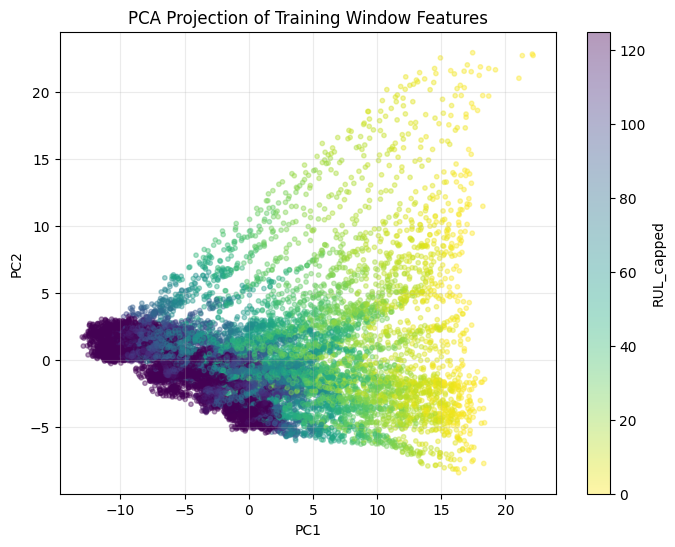

In [38]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train_tabular,
    cmap="viridis_r",
    alpha=0.4,
    s=10
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Training Window Features")
plt.colorbar(scatter, label=target_col)
plt.grid(True, alpha=0.25)

plt.show()

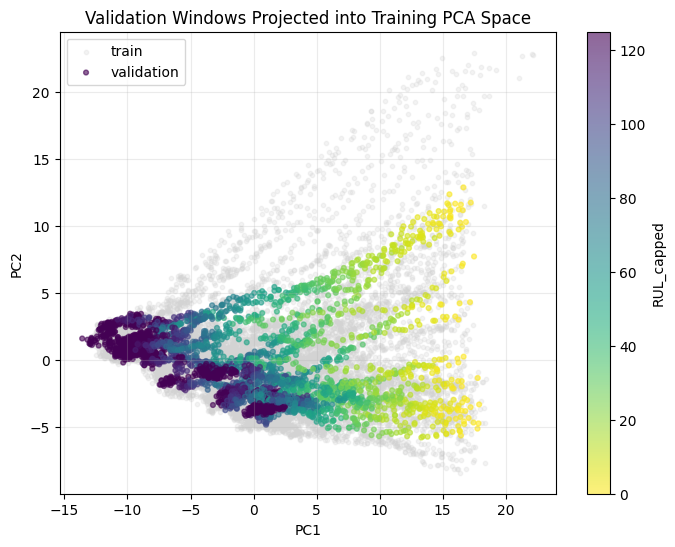

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c="lightgrey",
    alpha=0.25,
    s=10,
    label="train"
)

scatter = plt.scatter(
    X_val_pca[:, 0],
    X_val_pca[:, 1],
    c=y_val_tabular,
    cmap="viridis_r",
    alpha=0.6,
    s=12,
    label="validation"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Validation Windows Projected into Training PCA Space")
plt.colorbar(scatter, label=target_col)
plt.legend()
plt.grid(True, alpha=0.25)

plt.show()

In [40]:
# Ensure that PCA produces two components for every training tabular sample.
assert X_train_pca.shape == (X_train_tabular.shape[0], 2)

# Ensure that PCA produces two components for every validation tabular sample.
assert X_val_pca.shape == (X_val_tabular.shape[0], 2)

# Ensure that the two PCA components explain a non-negative fraction of variance.
assert (pca.explained_variance_ratio_ >= 0).all()

The PCA projection provides a low-dimensional view of the engineered window features. A visible color gradient with respect to `RUL_capped` would indicate that the engineered features contain degradation-related structure. However, PCA is linear and primarily used for visualization, so model performance must still be evaluated with supervised learning in Notebook 05.

# Feature Engineering Takeaways

This notebook transformed the preprocessed C-MAPSS time series into model-ready feature representations.

Sliding windows were created for each engine trajectory using a fixed window size. Each window contains a sequence of past sensor and setting values, while the target corresponds to the capped RUL at the final cycle of the window.

The generated sequence arrays have the shape `(samples, window_size, features)` and can later be used for deep learning models such as 1D-CNNs, LSTMs, TCNs or Transformer-based sequence models.

For classical machine learning models, each sequence window was converted into a tabular feature vector. Statistical descriptors such as mean, standard deviation, minimum, maximum, last value and linear slope were extracted for each input feature.

Engine and cycle metadata were kept separately from model inputs. This preserves traceability for later prediction analysis without leaking identifiers into the model features.

The resulting feature sets are:

- `X_train_windows`, `y_train_windows`
- `X_val_windows`, `y_val_windows`
- `X_test_windows`
- `X_train_tabular`, `y_train_tabular`
- `X_val_tabular`, `y_val_tabular`
- `X_test_tabular`
- `train_window_metadata`, `val_window_metadata`, `test_window_metadata`
- `tabular_feature_cols`

The sequence-based and tabular feature representations are ready for model training and evaluation in Notebook 05.

The PCA inspection provided a first visual check of the engineered feature space. PCA is used only for exploratory visualization at this stage and is not yet part of the modeling pipeline.